# Recruitment & Employee Retention Analytics

## Exploratory Data Analysis (EDA)

### Objective:
Analyze recruitment and employee data to identify:

- Hiring trends
- Applicant behavior
- Offer conversion patterns
- Salary distribution
- Employee retention factors
- Churn patterns

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="white")

# Business Questions


## 1. Job Listings Analysis

### Job Demand
- Which industries have the highest number of job postings?
- Which job titles are most in demand?
- Which countries have the highest hiring activity?
- Which cities have the highest number of job listings?
- Does company size affect job availability?
- Which employment types are most common?
- How does remote policy impact job listings?
- Which skills are most frequently required?
- Which technology stacks are most commonly used?
- Which experience levels have the highest job demand?

In [34]:
job_listings = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Global _market\Deployment\data\processed\job_listings.csv")

In [35]:
retention_kpis = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Global _market\Deployment\data\processed\retention_kpis.csv")

In [36]:
job_listings.shape

(250000, 15)

In [37]:
job_listings.info() 

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   job_id                250000 non-null  int64
 1   title                 250000 non-null  str  
 2   industry              250000 non-null  str  
 3   company_size          250000 non-null  str  
 4   company_tier          250000 non-null  str  
 5   country               250000 non-null  str  
 6   city                  250000 non-null  str  
 7   remote_policy         250000 non-null  str  
 8   experience_level      250000 non-null  str  
 9   education_required    250000 non-null  str  
 10  skills                250000 non-null  str  
 11  tech_stack            250000 non-null  str  
 12  employment_type       250000 non-null  str  
 13  posted_date           250000 non-null  str  
 14  application_deadline  250000 non-null  str  
dtypes: int64(1), str(14)
memory usage: 28.6 MB


In [38]:
for col in job_listings:
    print(f"-----------{col}----------")
    print(job_listings[col].unique())

-----------job_id----------
[     1      2      3 ... 249998 249999 250000]
-----------title----------
<StringArray>
[    'AI Researcher',  'Business Analyst',   'Cloud Architect',
     'Data Engineer',    'Data Scientist',   'DevOps Engineer',
   'Product Manager',       'QA Engineer', 'Software Engineer',
       'UX Designer']
Length: 10, dtype: str
-----------industry----------
<StringArray>
[       'Finance',      'Education',     'Technology',     'Healthcare',
         'Retail', 'Transportation',  'Manufacturing']
Length: 7, dtype: str
-----------company_size----------
<StringArray>
['51-200', '501-1000', '1-50', '10000+', '1001-5000', '201-500', '5001-10000']
Length: 7, dtype: str
-----------company_tier----------
<StringArray>
['Scale-up', 'Enterprise', 'Startup', 'MNC', 'Corporation', 'Mid-Market']
Length: 6, dtype: str
-----------country----------
<StringArray>
[                                 'Afghanistan',
                                      'Albania',
                  

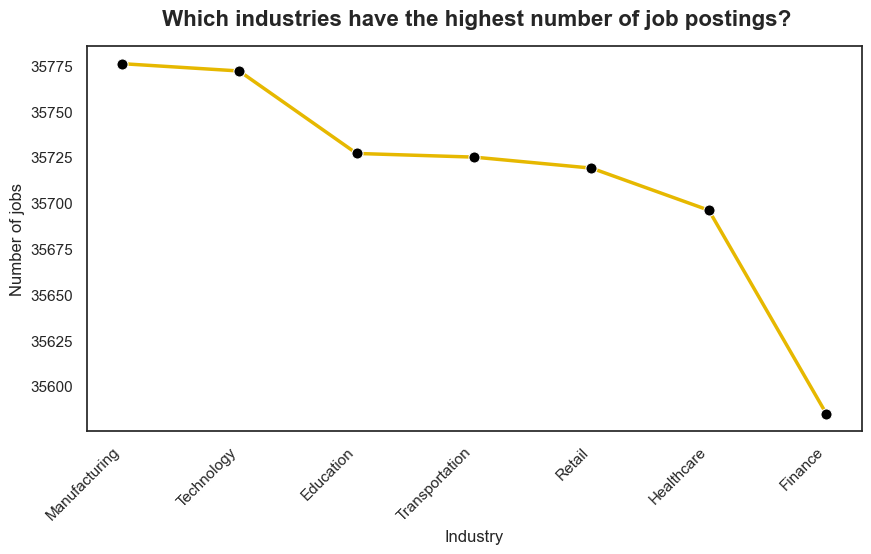

In [39]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=job_listings["industry"].value_counts(),
    marker="o",
    markersize=8, 
    color="#e6b800", 
    linewidth=2.5,
    markerfacecolor="#000000"
)
plt.title(" Which industries have the highest number of job postings?", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Number of jobs", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.show()

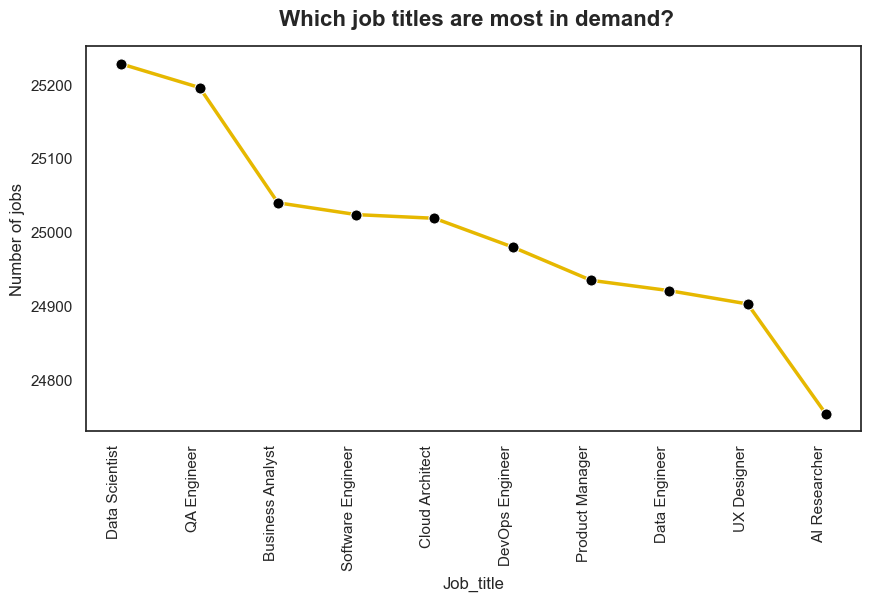

In [40]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=job_listings['title'].value_counts(),
    marker="o",
    markersize=8, 
    color="#e6b800", 
    linewidth=2.5,
    markerfacecolor="#000000"
)
plt.title(" Which job titles are most in demand?", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Job_title", fontsize=12)
plt.ylabel("Number of jobs", fontsize=12)

plt.xticks(rotation=90, ha="right")
plt.show()

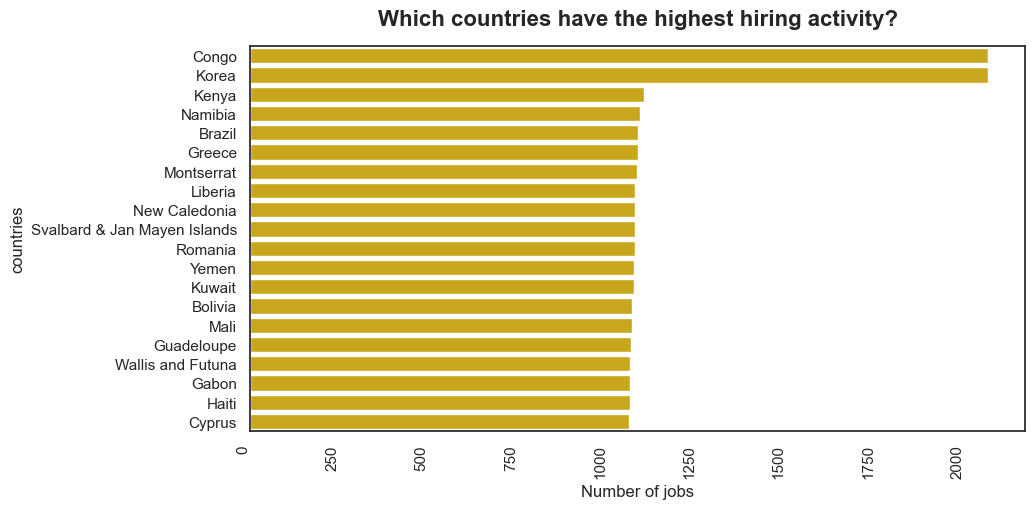

In [41]:
top_countries = job_listings['country'].value_counts().head(20)
plt.figure(figsize=(10, 5))
sns.barplot(
    x = top_countries.values ,
    y = top_countries.index ,
    color="#e6b800"
           )
plt.title("Which countries have the highest hiring activity?", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("countries", fontsize=12)
plt.xlabel("Number of jobs", fontsize=12)

plt.xticks(rotation=90, ha="right")
plt.show()

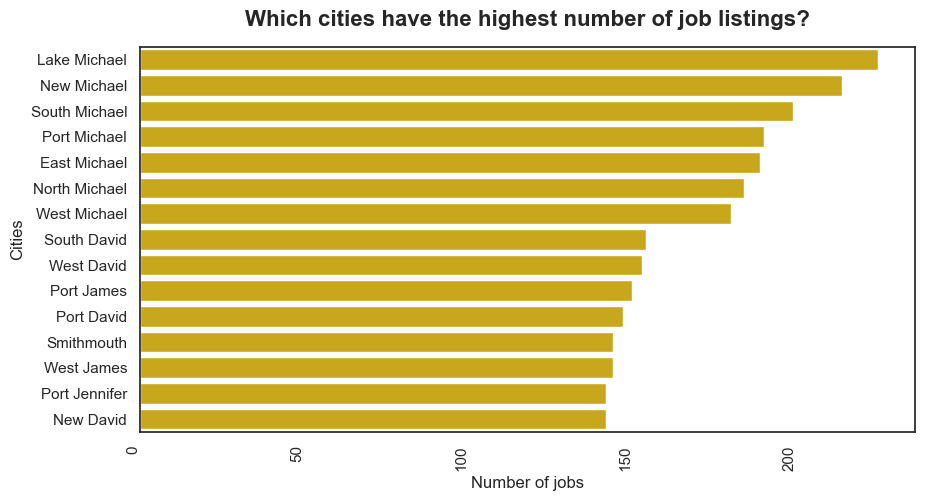

In [42]:
top_cities = job_listings['city'].value_counts().head(15)
top_cities
plt.figure(figsize=(10,5))
sns.barplot(
    x = top_cities.values,
    y = top_cities.index,
    color = '#e6b800'
)
plt.title("Which cities have the highest number of job listings?", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("Cities", fontsize=12)
plt.xlabel("Number of jobs", fontsize=12)
plt.xticks(rotation=90, ha="right")
plt.show()

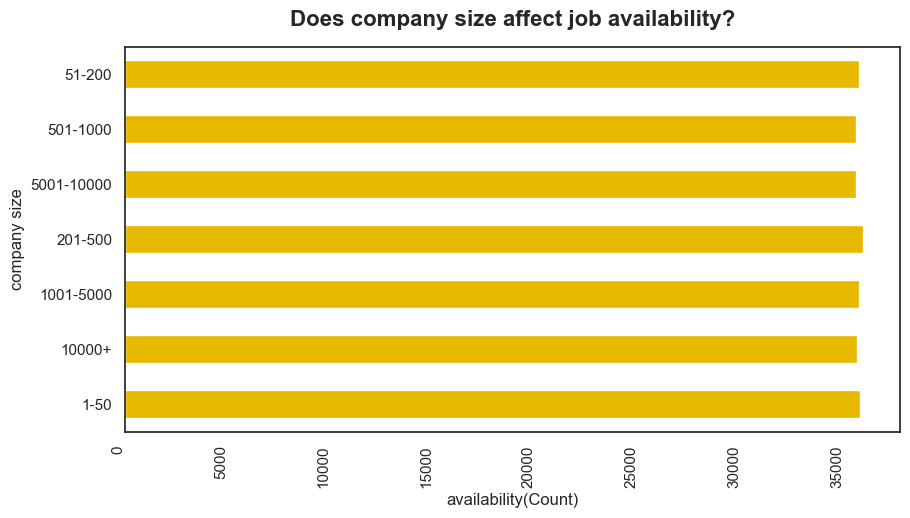

In [43]:
company = job_listings.groupby('company_size')['job_id'].count()


plt.figure(figsize=(10,5))
company.plot(
    kind = 'barh',
    color = '#e6b800'
)
# sns.barplot(
#     x = company.values,
#     y = company.index,
#     color = '#e6b800'
# )
plt.title("Does company size affect job availability?", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("company size", fontsize=12)
plt.xlabel("availability(Count)", fontsize=12)
plt.xticks(rotation=90, ha="right")
plt.show()

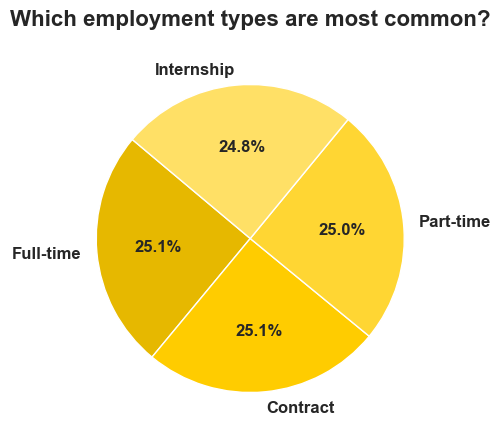

In [44]:
emp_type = job_listings['employment_type'].value_counts()
gold_suite = ["#e6b800", "#ffcc00", "#ffd633", "#ffe066"]
plt.figure(figsize=(10,5))
plt.pie(
    emp_type.values,
    labels = emp_type.index,
    autopct="%1.1f%%",
    startangle=140, 
    colors=gold_suite,
    textprops={"fontsize": 12, "fontweight": "semibold"}
);

plt.title("Which employment types are most common?", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=90, ha="right")
plt.show()

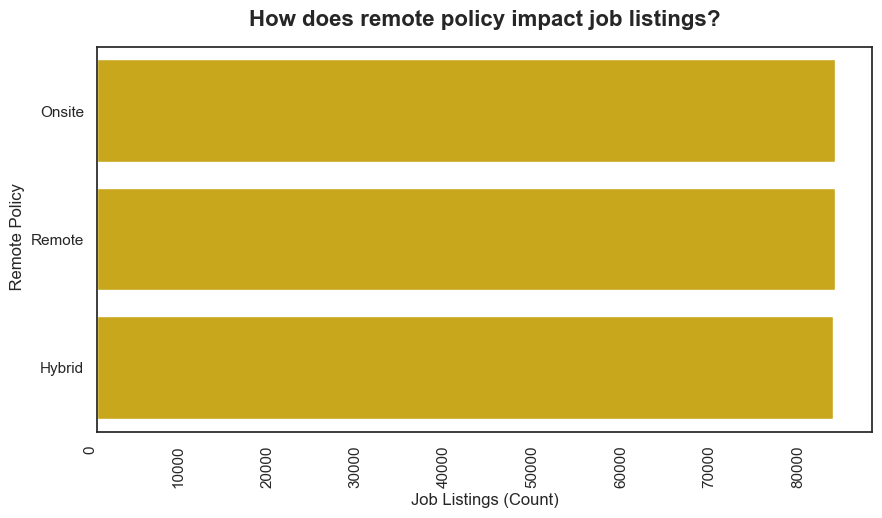

In [45]:
remote_impact = job_listings['remote_policy'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(
    x = remote_impact.values,
    y = remote_impact.index,
    color = '#e6b800'
)
plt.title("How does remote policy impact job listings?", fontsize=16, fontweight="bold", pad=15)
plt.ylabel(" Remote Policy", fontsize=12)
plt.xlabel("Job Listings (Count)", fontsize=12)
plt.xticks(rotation=90, ha="right")
plt.show()

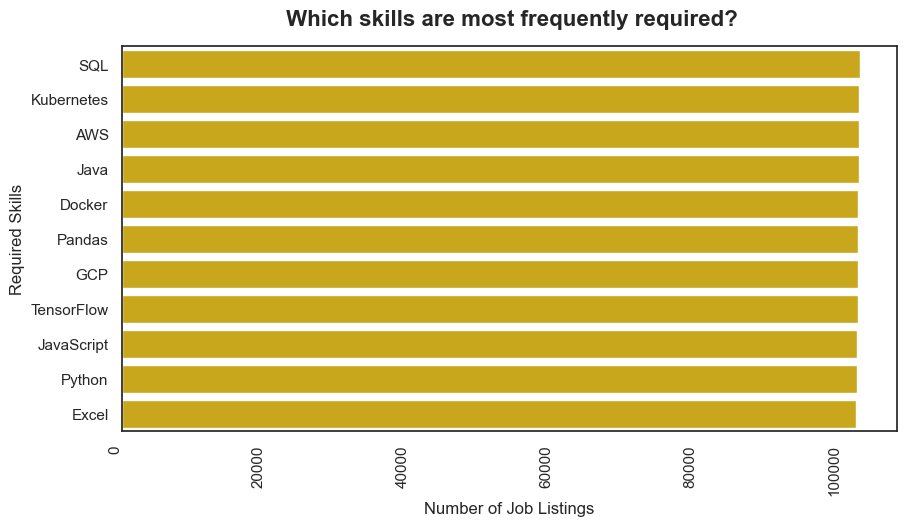

In [46]:
exploded_skils = job_listings['skills'].dropna().str.split(', ').explode()
top_skills = exploded_skils.value_counts().head(15)
plt.figure(figsize=(10,5))
sns.barplot(
    x = top_skills.values,
    y = top_skills.index,
    color = '#e6b800'
)
plt.title(" Which skills are most frequently required?", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("Required Skills", fontsize=12)
plt.xlabel("Number of Job Listings", fontsize=12)
plt.xticks(rotation=90, ha="right")
plt.show()

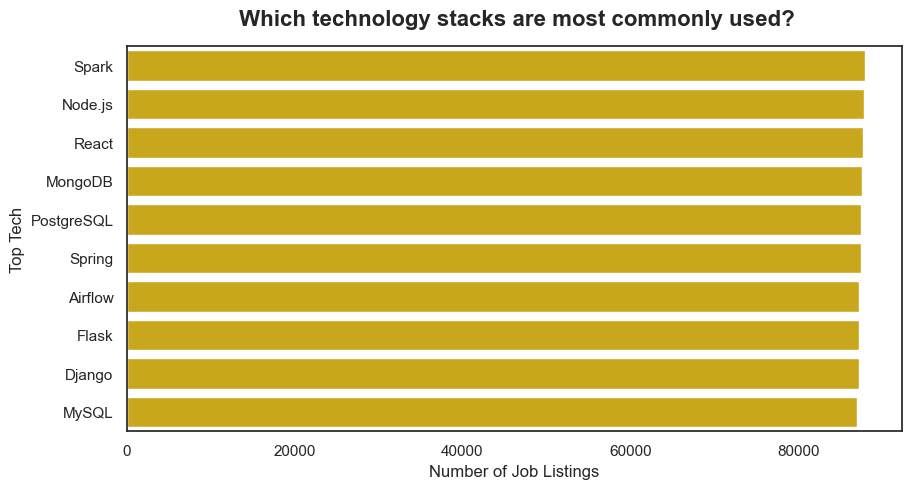

In [47]:
explode_stack = job_listings['tech_stack'].dropna().str.split(', ').explode()
top_tech  = explode_stack.value_counts()
plt.figure(figsize=(10,5))
sns.barplot(
    x = top_tech.values,
    y = top_tech.index,
    color = '#e6b800'
)
plt.title(" Which technology stacks are most commonly used?", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("Top Tech", fontsize=12)
plt.xlabel("Number of Job Listings", fontsize=12)
plt.show()

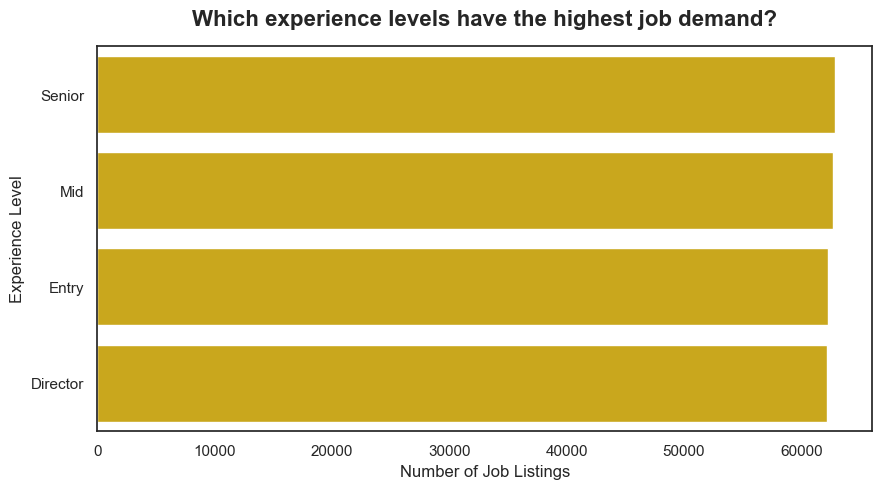

In [48]:
exp_level = job_listings['experience_level'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(
    x = exp_level.values,
    y = exp_level.index,
    color = '#e6b800'
)
plt.title("Which experience levels have the highest job demand?", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("Experience Level", fontsize=12)
plt.xlabel("Number of Job Listings", fontsize=12)
plt.show()

## 2. Recruitment KPIs Analysis

### Hiring Process Performance
- Which jobs receive the highest number of applicants?
- Which industries attract the most applicants?
- What is the overall offer acceptance rate?
- Which industries have the highest offer acceptance rate?
- Which job roles have the highest hiring success rate?
- Does remote work affect applicant volume?
- Does response time affect offer acceptance?
- Which companies have the fastest recruitment process?
- Which employment types have better hiring conversion?
- Which experience levels receive more offers?

In [49]:
recruitment_kpis = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Global _market\Deployment\data\processed\recruiting_kpis.csv")

In [50]:
recruitment_kpis.shape

(250000, 5)

In [51]:
recruitment_kpis.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   job_id              250000 non-null  int64
 1   num_applicants      250000 non-null  int64
 2   avg_response_hours  250000 non-null  str  
 3   offer_extended      250000 non-null  bool 
 4   offer_accepted      250000 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 6.2 MB


In [52]:
for col in recruitment_kpis:
    print(f"-----------{col}----------")
    print(recruitment_kpis[col].unique())

-----------job_id----------
[     1      2      3 ... 249998 249999 250000]
-----------num_applicants----------
[273 298 194 499 378 484  24 432 256 167 201  39  81 379 214 330 234 203
 215  64 262 101 200 251 263 335 163 467 400 310 213 172 197 156 175 170
 489  35 495 414  32  77 455 248 469 324 260 421 318 364 419 255 131 232
 326 446 373 236 212 168 404 384 487  56  72 104 328 359 490 154  50 223
 115 247 425  26  33 246 140 353 468 437 281  89  90 478 292 297 413 191
 327 220 103  12  71 466 187 394  84  85 340 241  15 366  23 389 411 229
 257 397 174  78 124 114 442 207 311   7 123 271 147 117 355 290 235 144
  53 403 447 276 266 285 127  66  52  36 429  22 343  43 208 250 309 233
 477 145 254 312 275 417  65 306 385  83 346  88 491 279 300 448 198 367
 337 492 274 376 258 444 426 180 325 139 204  92 398 202 225  96   5 228
 341 405 302 192 360 418 164 125 452  97 105 458  25  44 107 294  67 199
 135 182  68 193  55 322 150 482 122 288 334  59  20 449 278 237 470  70
 320 295 352

In [53]:
recruitment_analysis = job_listings.merge(
    recruitment_kpis,
    on = 'job_id'
)

In [54]:
recruitment_analysis.head()

,job_id,title,industry,company_size,company_tier,country,city,remote_policy,experience_level,education_required,skills,tech_stack,employment_type,posted_date,application_deadline,num_applicants,avg_response_hours,offer_extended,offer_accepted
0,1,AI Researcher,Finance,51-200,Scale-up,Afghanistan,Jessicahaven,Remote,Senior,Master's,"Python, TensorFlow, JavaScript, Kubernetes, AW...","Node.js, Spring, Spark",Contract,2024-03-07,2024-04-16,273,6-12,False,False
1,2,AI Researcher,Education,501-1000,Enterprise,Afghanistan,Jenniferfurt,Remote,Senior,Not-specified,"Excel, Docker, JavaScript, SQL, TensorFlow, Java","Django, Flask",Internship,2023-10-22,2023-11-12,298,6-12,True,True
2,3,AI Researcher,Finance,51-200,Scale-up,Afghanistan,North Charles,Onsite,Mid,Not-specified,"Excel, Java, AWS","React, Node.js, Spring",Internship,2024-12-08,2025-01-04,194,6-12,False,False
3,4,AI Researcher,Technology,501-1000,Enterprise,Afghanistan,Benjaminhaven,Hybrid,Entry,Master's,"Pandas, GCP, Docker, Java, JavaScript","Node.js, Airflow, MongoDB",Full-time,2025-07-08,2025-09-02,499,6-12,False,False
4,5,AI Researcher,Healthcare,501-1000,Enterprise,Afghanistan,Port Daniel,Onsite,Entry,Bachelor's,"Python, Pandas, Java","PostgreSQL, Flask, MongoDB",Full-time,2024-01-04,2024-02-24,378,6-12,False,False


In [55]:
recruitment_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   job_id                250000 non-null  int64
 1   title                 250000 non-null  str  
 2   industry              250000 non-null  str  
 3   company_size          250000 non-null  str  
 4   company_tier          250000 non-null  str  
 5   country               250000 non-null  str  
 6   city                  250000 non-null  str  
 7   remote_policy         250000 non-null  str  
 8   experience_level      250000 non-null  str  
 9   education_required    250000 non-null  str  
 10  skills                250000 non-null  str  
 11  tech_stack            250000 non-null  str  
 12  employment_type       250000 non-null  str  
 13  posted_date           250000 non-null  str  
 14  application_deadline  250000 non-null  str  
 15  num_applicants        250000 non-null  int64


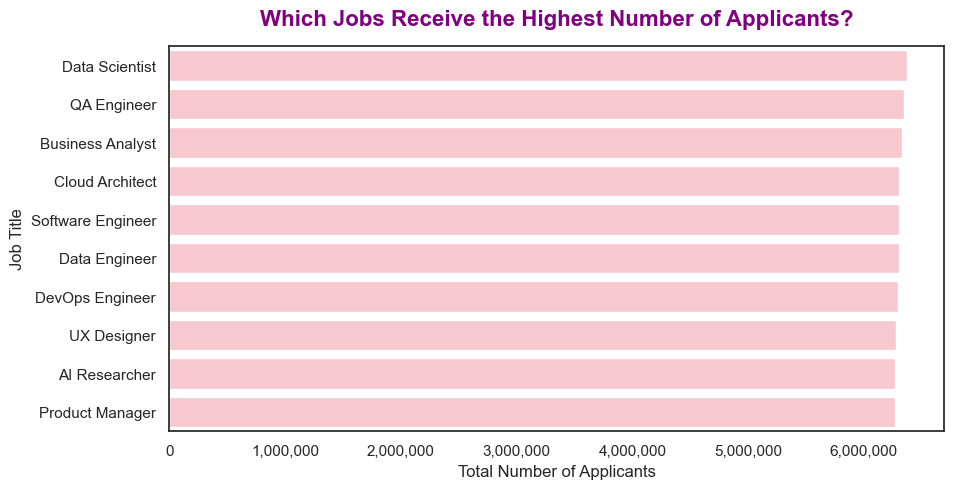

In [56]:
num_of_applications = recruitment_analysis.groupby('title')['num_applicants'].sum().sort_values(ascending=False)
num_of_applications.value_counts( normalize = False) * 100

plt.figure(figsize=(10, 5))
sns.barplot(
    x=num_of_applications.values,
    y=num_of_applications.index,
    color="#FFC0CB",
)

plt.title(
    "Which Jobs Receive the Highest Number of Applicants?",
    fontsize=16,
    fontweight="bold",
    color="#800080",
    pad=15,
)
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.xlabel("Total Number of Applicants", fontsize=12)
plt.ylabel("Job Title", fontsize=12)
plt.show()


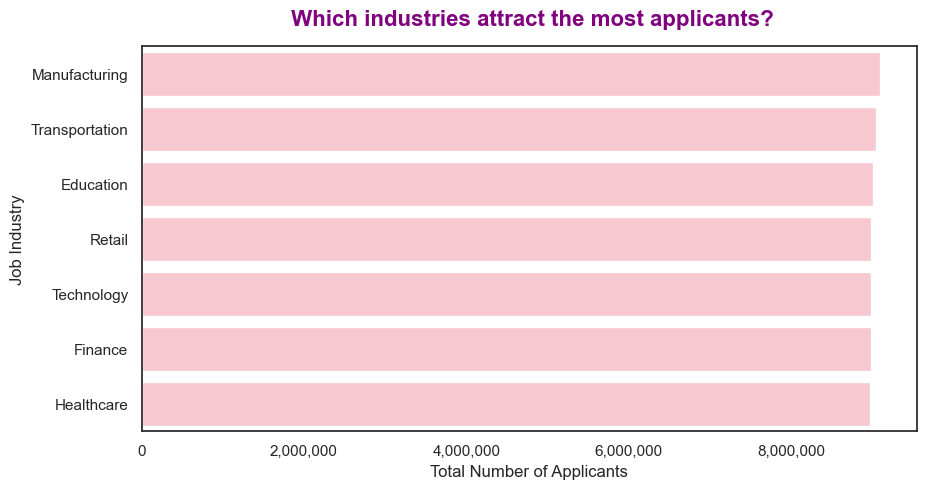

In [57]:
industry_applicant = recruitment_analysis.groupby('industry')['num_applicants'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=industry_applicant.values,
    y=industry_applicant.index,
    color="#FFC0CB",

)
plt.title(
    " Which industries attract the most applicants?",
    fontsize=16,
    fontweight="bold",
    color="#800080",
    pad=15,
)
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.xlabel("Total Number of Applicants", fontsize=12)
plt.ylabel("Job Industry", fontsize=12)
plt.show()

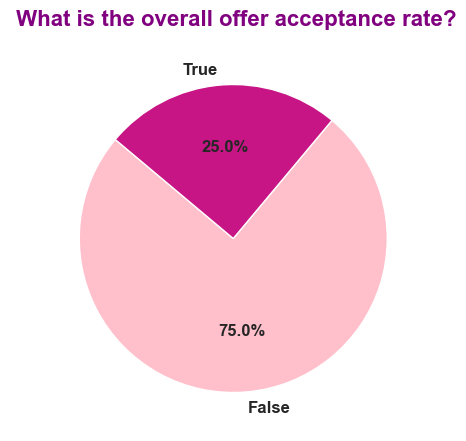

In [58]:
acceptance_rate = recruitment_analysis['offer_accepted'].value_counts(normalize = True) * 100
pink_colors =['#FFC0CB','#C71585', '#FF69B4']

plt.figure(figsize=(10, 5))

plt.pie(
    acceptance_rate.values,
    labels = acceptance_rate.index,
    autopct="%1.1f%%",
    startangle=140, 
    colors=pink_colors,
    textprops={"fontsize": 12, "fontweight": "semibold"}
);

plt.title(
    " What is the overall offer acceptance rate?",
    fontsize=16,
    fontweight="bold",
    color="#800080",
    pad=15,
)

plt.show()

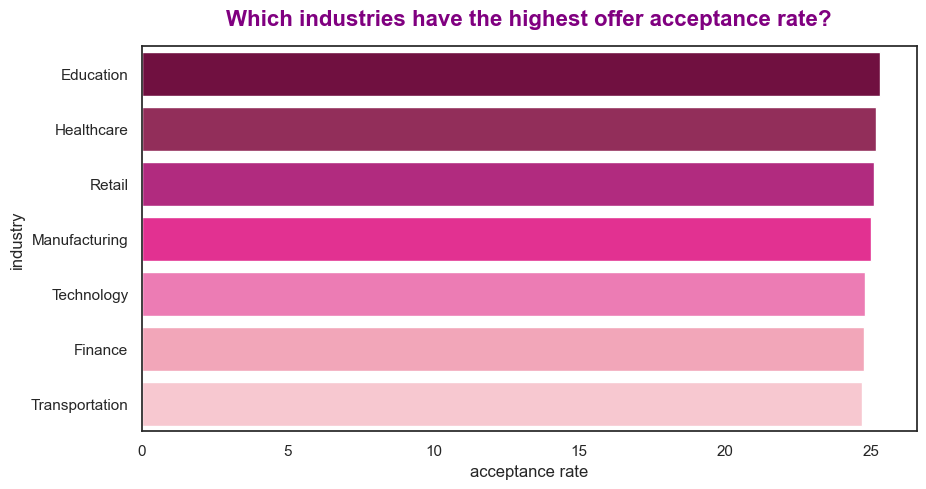

In [59]:
industries_rate =  recruitment_analysis.groupby('industry')['offer_accepted'].mean() * 100
industries_rate = industries_rate.sort_values(ascending=False)
industrie_colors = ['#800040', '#A31D58', '#C71585', '#FF1493', '#FF69B4', '#FF99B2', '#FFC0CB']

plt.figure(figsize=(10, 5))

sns.barplot(
    x = industries_rate.values,
    y = industries_rate.index,
    palette=industrie_colors,
);

plt.title(
    "Which industries have the highest offer acceptance rate?",
    fontsize=16,
    fontweight="bold",
    color="#800080",
    pad=15,
)
plt.xlabel("acceptance rate")

plt.show()

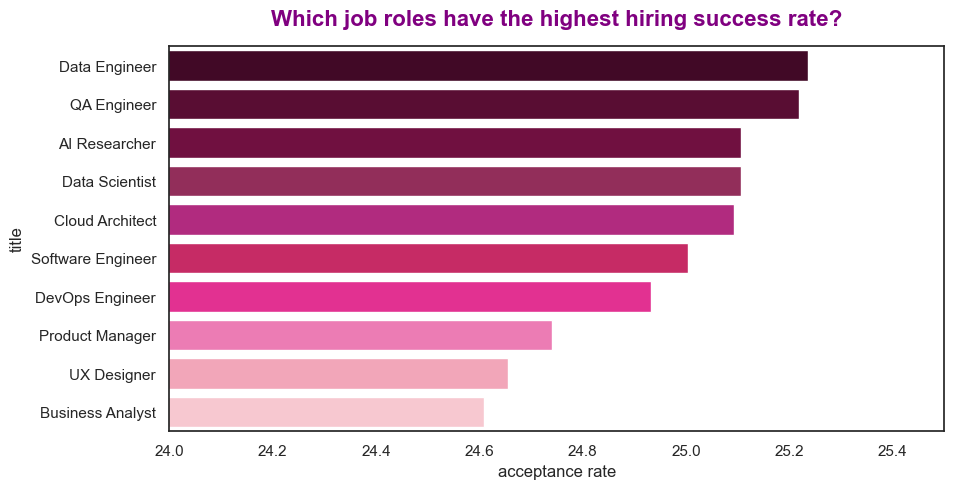

In [60]:
job_acceptance = recruitment_analysis.groupby('title')['offer_accepted'].mean() * 100
job_acceptance = job_acceptance.sort_values(ascending = False)
title_colors = [
    '#4A0026', '#660033', '#800040', '#A31D58', '#C71585', 
    '#E0115F', '#FF1493', '#FF69B4', '#FF99B2', '#FFC0CB', '#FFE4E1'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x = job_acceptance.values,
    y = job_acceptance.index,
    palette = title_colors
)

plt.title(
    "Which job roles have the highest hiring success rate?",
    fontsize=16,
    fontweight="bold",
    color="#800080",
    pad=15,
)
plt.xlabel("acceptance rate")
plt.xlim(24,25.5)
plt.show()

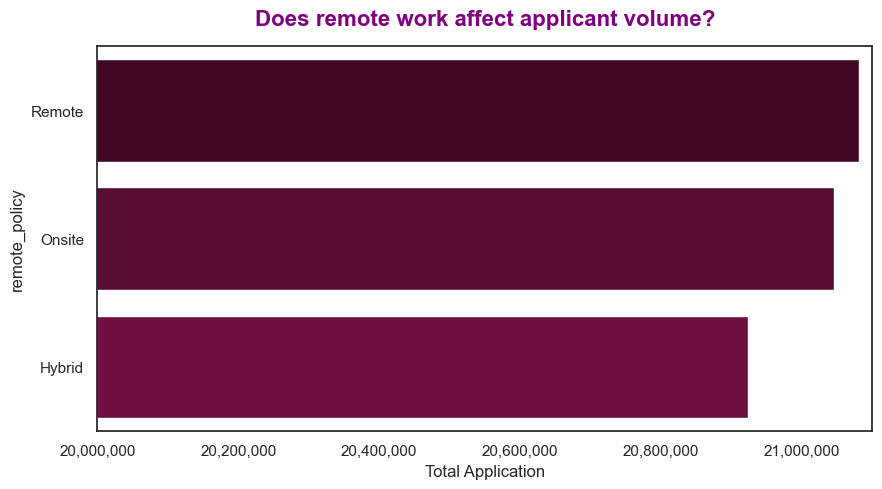

In [61]:
total_remote_applicant = recruitment_analysis.groupby('remote_policy')['num_applicants'].sum()
total_remote_applicant = total_remote_applicant.sort_values(ascending=False)
title_colors = [
    '#4A0026', '#660033', '#800040', '#A31D58', '#C71585', 
    '#E0115F', '#FF1493', '#FF69B4', '#FF99B2', '#FFC0CB', '#FFE4E1'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x = total_remote_applicant.values,
    y = total_remote_applicant.index,
    palette = title_colors
)

plt.title(
    "Does remote work affect applicant volume?",
    fontsize=16,
    fontweight="bold",
    color="#800080",
    pad=15,
)
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
plt.xlabel("Total Application")
plt.xlim(20000000,21100000)

plt.show()

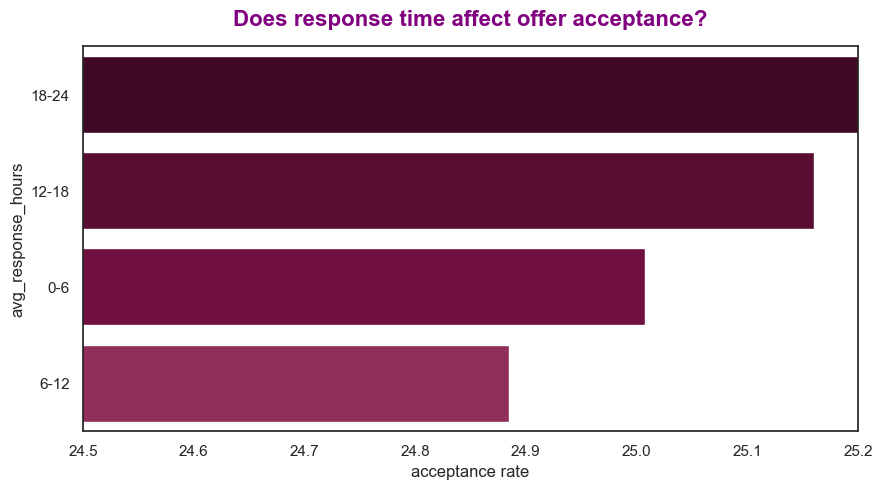

In [62]:
acceptance_time = recruitment_analysis.groupby('avg_response_hours')['offer_accepted'].mean() * 100
acceptance_time = acceptance_time.sort_values(ascending = False)

title_colors = [
    '#4A0026', '#660033', '#800040', '#A31D58', '#C71585', 
    '#E0115F', '#FF1493', '#FF69B4', '#FF99B2', '#FFC0CB', '#FFE4E1'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x = acceptance_time.values,
    y = acceptance_time.index,
    palette = title_colors
)

plt.title(
    "Does response time affect offer acceptance?",
    fontsize=16,
    fontweight="bold",
    color="#800080",
    pad=15,
)
plt.xlabel("acceptance rate")
plt.xlim(24.5, 25.2)


plt.show()

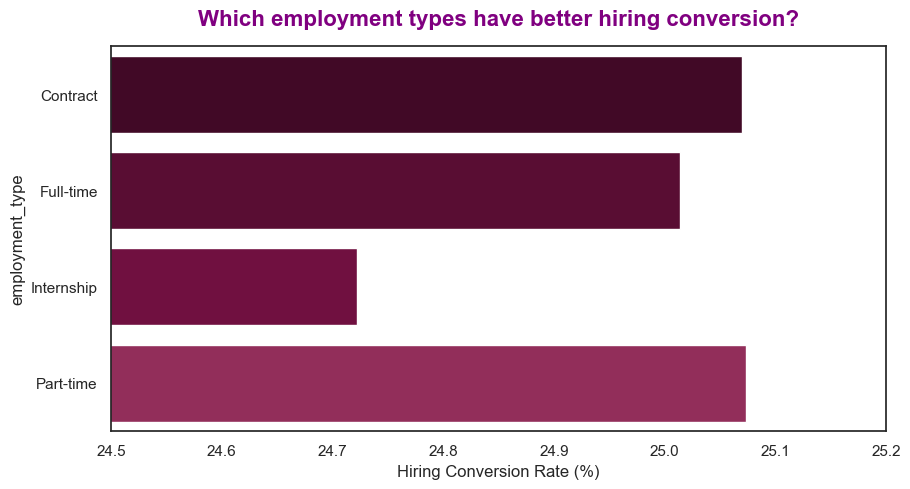

In [63]:
emp_hire = recruitment_analysis.groupby('employment_type')['offer_accepted'].mean() * 100
emp_hire

title_colors = [
    '#4A0026', '#660033', '#800040', '#A31D58', '#C71585', 
    '#E0115F', '#FF1493', '#FF69B4', '#FF99B2', '#FFC0CB', '#FFE4E1'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x = emp_hire.values,
    y = emp_hire.index,
    palette = title_colors
)

plt.title(
    "Which employment types have better hiring conversion?",
    fontsize=16,
    fontweight="bold",
    color="#800080",
    pad=15,
)
plt.xlabel("Hiring Conversion Rate (%)")
plt.xlim(24.5, 25.2)

plt.show()

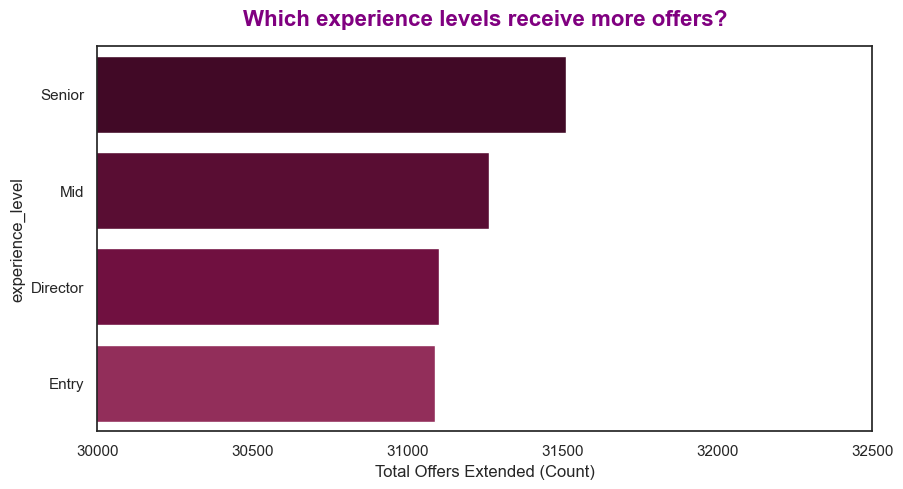

In [64]:
# Which experience levels receive more offers?
exp_hire = recruitment_analysis.groupby('experience_level')['offer_extended'].sum()
exp_hire = exp_hire.sort_values(ascending = False)
title_colors = [
    '#4A0026', '#660033', '#800040', '#A31D58', '#C71585', 
    '#E0115F', '#FF1493', '#FF69B4', '#FF99B2', '#FFC0CB', '#FFE4E1'
]
plt.figure(figsize=(10,5))

sns.barplot(
    x = exp_hire.values,
    y = exp_hire.index,
    palette = title_colors
)

plt.title(
    "Which experience levels receive more offers?",
    fontsize=16,
    fontweight="bold",
    color="#800080",
    pad=15,
)
plt.xlabel("Total Offers Extended (Count)")

plt.xlim(30000, 32500)
plt.show()

## 3. Retention KPIs Analysis

### Employee Retention & Churn
- What is the overall employee churn rate?
- Which industries have the highest employee churn?
- Does salary impact employee retention?
- Which experience levels have the highest churn?
- Which job roles have the highest churn rate?
- What is the average employee tenure?
- Which company sizes have better retention?
- Does salary differ between retained and churned employees?
- Which roles have the longest employee tenure?
- What factors are associated with employee turnover?

In [65]:
retention_kpis = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Global _market\Deployment\data\processed\retention_kpis.csv")

In [66]:
retention_kpis.head()

,job_id,starting_salary,tenure_months,churned_within_1yr
0,2,79095.83,23,False
1,10,98917.21,18,False
2,14,87016.68,10,True
3,16,89852.34,11,True
4,17,65377.76,9,True


In [67]:
retention_kpis.shape

(62426, 4)

In [68]:
retention_kpis.info()

<class 'pandas.DataFrame'>
RangeIndex: 62426 entries, 0 to 62425
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_id              62426 non-null  int64  
 1   starting_salary     62426 non-null  float64
 2   tenure_months       62426 non-null  int64  
 3   churned_within_1yr  62426 non-null  bool   
dtypes: bool(1), float64(1), int64(2)
memory usage: 1.5 MB


In [69]:
retention_analysis = recruitment_analysis.merge(
    retention_kpis,
    on = 'job_id'
)

In [70]:
retention_analysis.head().T

,0,1,2,3,4
job_id,2,10,14,16,17
title,AI Researcher,AI Researcher,AI Researcher,AI Researcher,AI Researcher
industry,Education,Retail,Technology,Finance,Education
company_size,501-1000,1001-5000,201-500,51-200,1001-5000
company_tier,Enterprise,Corporation,Mid-Market,Scale-up,Corporation
country,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan
city,Jenniferfurt,Kennethtown,Tapiaburgh,Sharpville,Smithfurt
remote_policy,Remote,Remote,Remote,Onsite,Hybrid
experience_level,Senior,Director,Director,Director,Director
education_required,Not-specified,PhD,PhD,Master's,Bachelor's


In [71]:
retention_analysis.shape

(62426, 22)

In [72]:
retention_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 62426 entries, 0 to 62425
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_id                62426 non-null  int64  
 1   title                 62426 non-null  str    
 2   industry              62426 non-null  str    
 3   company_size          62426 non-null  str    
 4   company_tier          62426 non-null  str    
 5   country               62426 non-null  str    
 6   city                  62426 non-null  str    
 7   remote_policy         62426 non-null  str    
 8   experience_level      62426 non-null  str    
 9   education_required    62426 non-null  str    
 10  skills                62426 non-null  str    
 11  tech_stack            62426 non-null  str    
 12  employment_type       62426 non-null  str    
 13  posted_date           62426 non-null  str    
 14  application_deadline  62426 non-null  str    
 15  num_applicants        62426 no

In [73]:
for col in retention_analysis:
    print(f"-------{col}--------")
    print(retention_analysis[col].unique())

-------job_id--------
[     2     10     14 ... 249979 249987 249990]
-------title--------
<StringArray>
[    'AI Researcher',  'Business Analyst',   'Cloud Architect',
     'Data Engineer',    'Data Scientist',   'DevOps Engineer',
   'Product Manager',       'QA Engineer', 'Software Engineer',
       'UX Designer']
Length: 10, dtype: str
-------industry--------
<StringArray>
[     'Education',         'Retail',     'Technology',        'Finance',
  'Manufacturing', 'Transportation',     'Healthcare']
Length: 7, dtype: str
-------company_size--------
<StringArray>
['501-1000', '1001-5000', '201-500', '51-200', '5001-10000', '10000+', '1-50']
Length: 7, dtype: str
-------company_tier--------
<StringArray>
['Enterprise', 'Corporation', 'Mid-Market', 'Scale-up', 'MNC', 'Startup']
Length: 6, dtype: str
-------country--------
<StringArray>
[                                 'Afghanistan',
                                      'Albania',
                                      'Algeria',
     

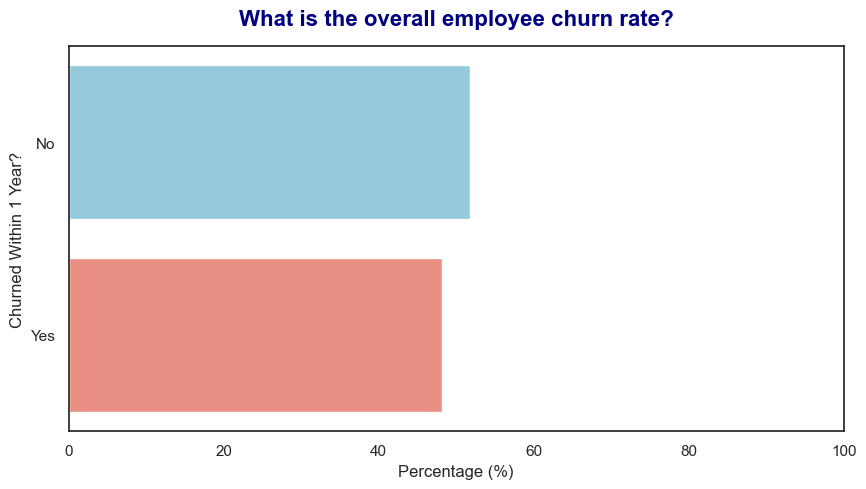

In [74]:
overall_churn = retention_analysis['churned_within_1yr'].value_counts(normalize = True) * 100
overall_churn.index = overall_churn.index.map({True: 'Yes', False: 'No'})

my_colors = ['skyblue', 'salmon']

plt.figure(figsize=(10,5))

sns.barplot(
    x=overall_churn.values, 
    y=overall_churn.index, 
    palette=my_colors,
    orient='h',
    hue=overall_churn.index,
)

plt.title(
    "What is the overall employee churn rate?",
    fontsize=16,
    fontweight="bold",
    color="navy",
    pad=15,
)
plt.xlabel("Percentage (%)")
plt.ylabel("Churned Within 1 Year?")
plt.xlim(0, 100)

plt.show()

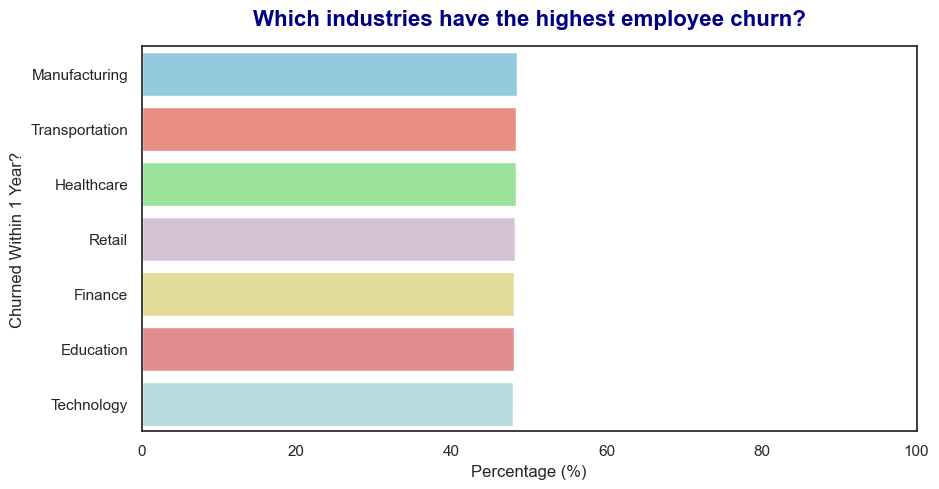

In [75]:
industry_churn = (retention_analysis.groupby('industry')['churned_within_1yr'].mean() * 100).sort_values(ascending = False)

my_colors = [
    'skyblue', 'salmon', 'lightgreen', 'thistle', 'khaki', 
    'lightcoral', 'powderblue', 'moccasin', 'lightpink', 'aquamarine'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=industry_churn.values, 
    y=industry_churn.index, 
    palette=my_colors,
    orient='h',
)

plt.title(
    "Which industries have the highest employee churn?",
    fontsize=16,
    fontweight="bold",
    color="navy",
    pad=15,
)
plt.xlabel("Percentage (%)")
plt.ylabel("Churned Within 1 Year?")
plt.xlim(0, 100)

plt.show()

In [76]:
#  Does salary impact employee retention?

retention_analysis['salary_group'] = pd.qcut(
    retention_analysis['starting_salary'], 
    q=3, 
    labels=['Low Pay', 'Medium Pay', 'High Pay']
)
salary_ranges = retention_analysis.groupby('salary_group')['starting_salary'].agg(['min', 'max', 'count'])
salary_ranges


,min,max,count
salary_group,,,
Low Pay,18055.47,78532.47,20809
Medium Pay,78533.04,91395.20,20808
High Pay,91395.29,144653.02,20809


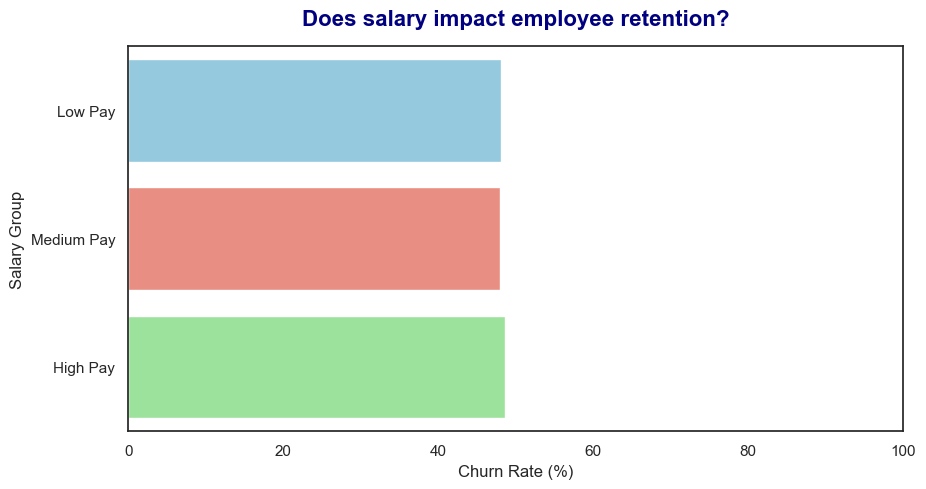

In [77]:
salary_case_churn = retention_analysis.groupby('salary_group')['churned_within_1yr'] .mean() * 100

my_colors = [
    'skyblue', 'salmon', 'lightgreen', 'thistle', 'khaki', 
    'lightcoral', 'powderblue', 'moccasin', 'lightpink', 'aquamarine'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=salary_case_churn.values, 
    y=salary_case_churn.index, 
    palette=my_colors,
    orient='h',
)

plt.title(
    "Does salary impact employee retention?",
    fontsize=16,
    fontweight="bold",
    color="navy",
    pad=15,
)
plt.xlabel("Churn Rate (%)")
plt.ylabel("Salary Group")
plt.xlim(0, 100)

plt.show()

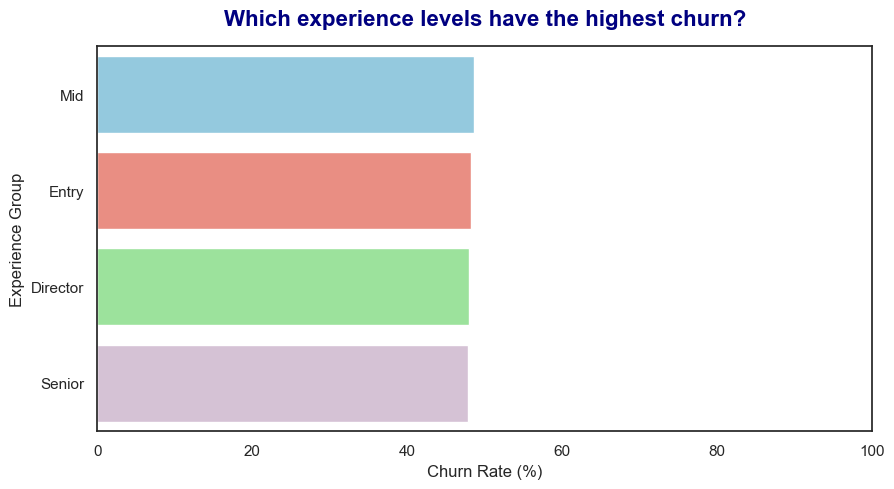

In [78]:
# Which experience levels have the highest churn?
exp_churn = ( retention_analysis.groupby('experience_level')['churned_within_1yr'] .mean() * 100 ).sort_values(ascending = False)

my_colors = [
    'skyblue', 'salmon', 'lightgreen', 'thistle', 'khaki', 
    'lightcoral', 'powderblue', 'moccasin', 'lightpink', 'aquamarine'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=exp_churn.values, 
    y=exp_churn.index, 
    palette=my_colors,
    orient='h',
)

plt.title(
    "Which experience levels have the highest churn?",
    fontsize=16,
    fontweight="bold",
    color="navy",
    pad=15,
)
plt.xlabel("Churn Rate (%)")
plt.ylabel("Experience Group")
plt.xlim(0, 100)

plt.show()

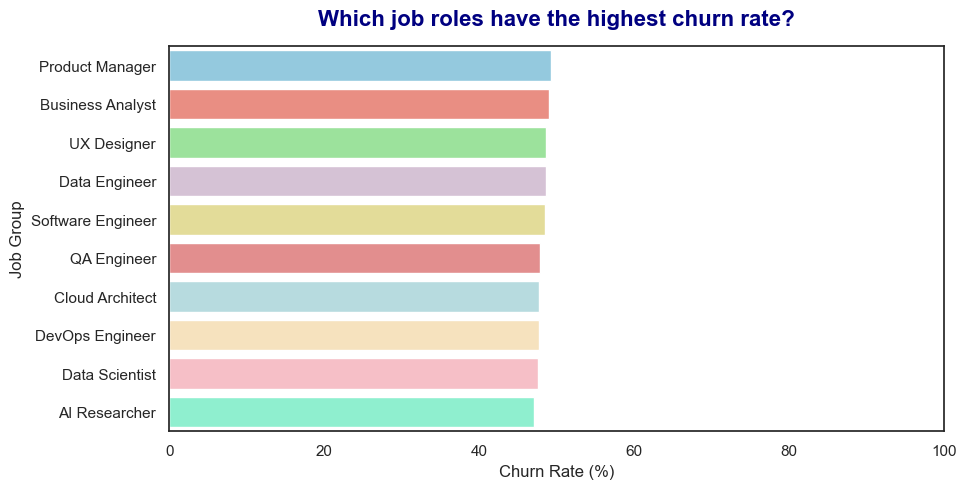

In [79]:
job_churn = ( retention_analysis.groupby('title')['churned_within_1yr'] .mean() * 100 ).sort_values(ascending = False)

my_colors = [
    'skyblue', 'salmon', 'lightgreen', 'thistle', 'khaki', 
    'lightcoral', 'powderblue', 'moccasin', 'lightpink', 'aquamarine'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=job_churn.values, 
    y=job_churn.index, 
    palette=my_colors,
    orient='h',
)

plt.title(
    "Which job roles have the highest churn rate?",
    fontsize=16,
    fontweight="bold",
    color="navy",
    pad=15,
)
plt.xlabel("Churn Rate (%)")
plt.ylabel("Job Group")
plt.xlim(0, 100)

plt.show()

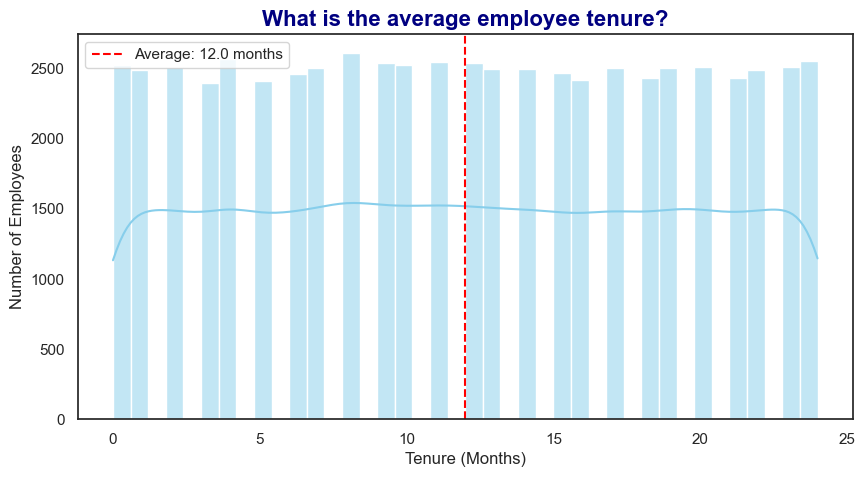

In [80]:

plt.figure(figsize=(10, 5))

# Plot the distribution of tenure months
sns.histplot(data=retention_analysis, x='tenure_months', kde=True, color='skyblue')

# Add a vertical dashed line to mark the mathematical average (mean)
plt.axvline(retention_analysis['tenure_months'].mean(), color='red', linestyle='--', label=f"Average: {retention_analysis['tenure_months'].mean():.1f} months")

# Styling
plt.title("What is the average employee tenure?", fontsize=16, fontweight='bold', color='navy')
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Employees")
plt.legend()

plt.show()


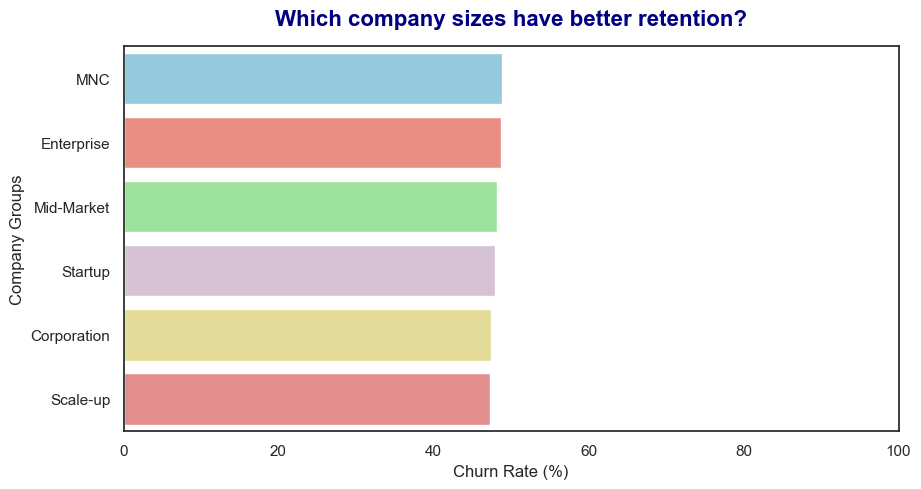

In [81]:
company_churn = ( retention_analysis.groupby('company_tier')['churned_within_1yr'] .mean() * 100 ).sort_values(ascending = False)

my_colors = [
    'skyblue', 'salmon', 'lightgreen', 'thistle', 'khaki', 
    'lightcoral', 'powderblue', 'moccasin', 'lightpink', 'aquamarine'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=company_churn.values, 
    y=company_churn.index, 
    palette=my_colors,
    orient='h',
)

plt.title(
    "Which company sizes have better retention?",
    fontsize=16,
    fontweight="bold",
    color="navy",
    pad=15,
)
plt.xlabel("Churn Rate (%)")
plt.ylabel("Company Groups")
plt.xlim(0, 100)

plt.show()

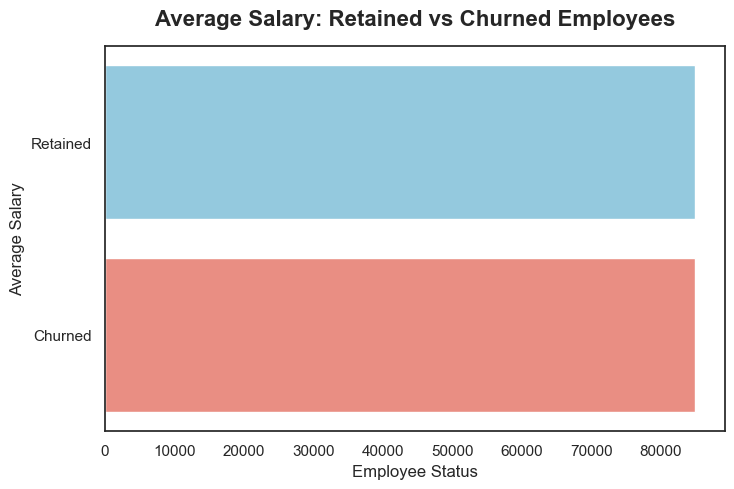

In [82]:
# Does salary differ between retained and churned employees?
salary_retention = (
    retention_analysis
    .groupby('churned_within_1yr')['starting_salary']
    .mean()
)

salary_retention.index = salary_retention.index.map({
    True: 'Churned',
    False: 'Retained'
})

my_colors = [
    'skyblue', 'salmon', 'lightgreen', 'thistle', 'khaki', 
    'lightcoral', 'powderblue', 'moccasin', 'lightpink', 'aquamarine'
]

plt.figure(figsize=(8,5))

sns.barplot(
    y=salary_retention.index,
    x=salary_retention.values,
    palette=my_colors,
    orient='h',
)

plt.title(
    "Average Salary: Retained vs Churned Employees",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Employee Status")
plt.ylabel("Average Salary")

plt.show()

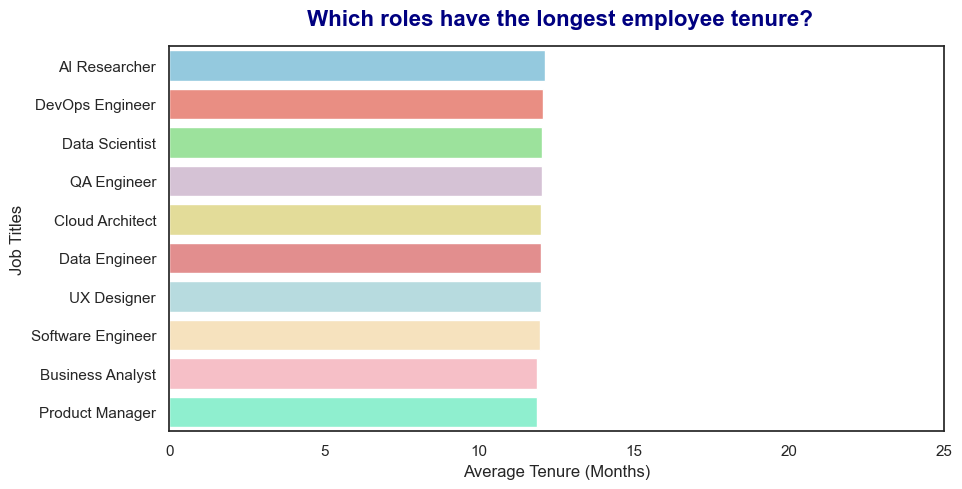

In [83]:
emp_tenure = ( retention_analysis.groupby('title')['tenure_months'].mean()).sort_values(ascending = False)
my_colors = [
    'skyblue', 'salmon', 'lightgreen', 'thistle', 'khaki', 
    'lightcoral', 'powderblue', 'moccasin', 'lightpink', 'aquamarine'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=emp_tenure.values, 
    y=emp_tenure.index, 
    palette=my_colors,
    orient='h',
)

plt.title(
    " Which roles have the longest employee tenure?",
    fontsize=16,
    fontweight="bold",
    color="navy",
    pad=15,
)
plt.xlabel("Average Tenure (Months)")
plt.ylabel("Job Titles")
plt.xlim(0, 25)

plt.show()